Training MLP from scratch …
Final Accuracy: 0.992


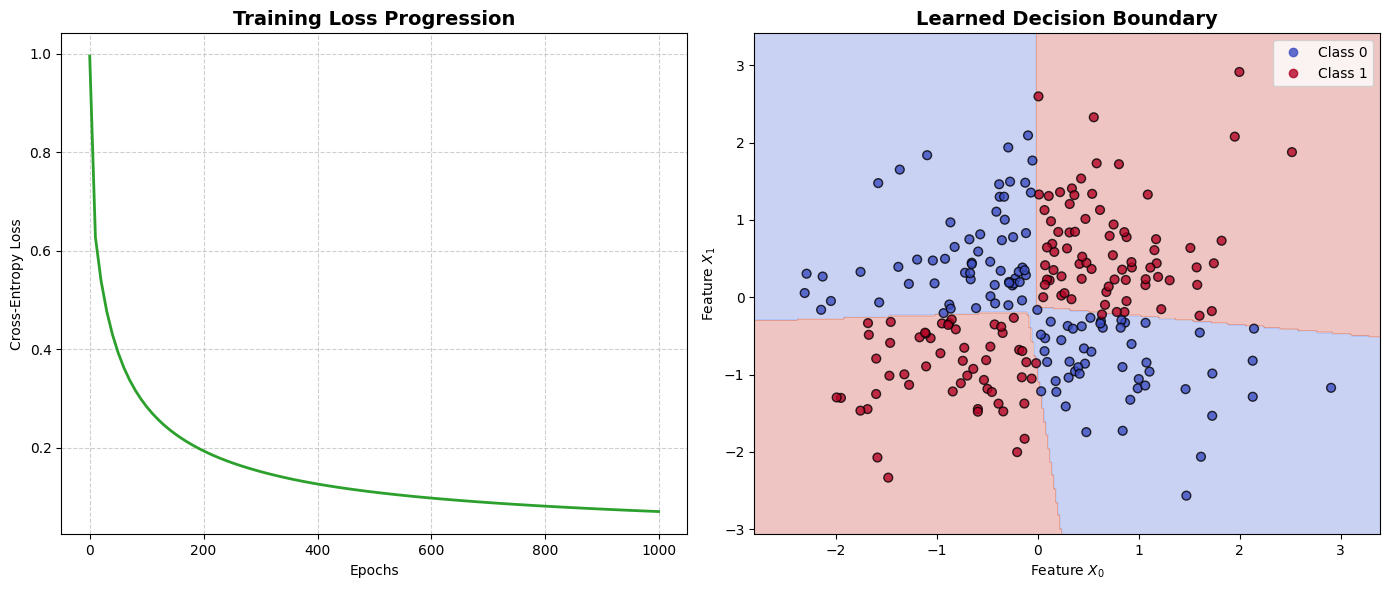

In [1]:
"""
Multilayer Perceptron (MLP) — NumPy From Scratch with Visualization
===================================================================
Architecture : Input(2) → Hidden(12, ReLU) → Output(2, Softmax)
Task         : Binary classification on a simple nonlinear dataset
Training     : Batch gradient descent with cross-entropy loss tracking
"""

import matplotlib.pyplot as plt
import numpy as np

# ── Reproducibility ──────────────────────────────────────────────────────────
rng = np.random.default_rng(42)


# ── Dataset ──────────────────────────────────────────────────────────────────
def make_dataset(n: int = 240):
    """Generate a simple 2-D nonlinear binary classification dataset."""
    X = rng.normal(size=(n, 2))
    # Label is 1 when x0*x1 + 0.25*x0 > 0
    y = ((X[:, 0] * X[:, 1] + 0.25 * X[:, 0]) > 0).astype(int)
    Y = np.eye(2)[y]  # one-hot encode labels
    return X, y, Y


# ── Activation functions ──────────────────────────────────────────────────────
def relu(z: np.ndarray) -> np.ndarray:
    """Rectified Linear Unit: max(0, z)."""
    return np.maximum(0, z)


def softmax(z: np.ndarray) -> np.ndarray:
    """Numerically stable row-wise softmax."""
    exp_z = np.exp(z - z.max(axis=1, keepdims=True))
    return exp_z / exp_z.sum(axis=1, keepdims=True)


# ── Weight initialisation ─────────────────────────────────────────────────────
def init_weights(input_dim: int = 2, hidden_dim: int = 12, output_dim: int = 2):
    """He/Xavier hybrid normal initialisation for stability."""
    W1 = rng.normal(scale=np.sqrt(2.0 / input_dim), size=(input_dim, hidden_dim))
    b1 = np.zeros(hidden_dim)
    W2 = rng.normal(scale=np.sqrt(1.0 / hidden_dim), size=(hidden_dim, output_dim))
    b2 = np.zeros(output_dim)
    return W1, b1, W2, b2


# ── Forward pass ──────────────────────────────────────────────────────────────
def forward(X, W1, b1, W2, b2):
    """Compute hidden activations and output probabilities.

    Returns cached values for efficient backpropagation.
    """
    z1 = X @ W1 + b1  # hidden layer pre-activation
    h1 = relu(z1)  # hidden layer activation
    z2 = h1 @ W2 + b2  # output layer pre-activation
    p = softmax(z2)  # output probabilities
    return z1, h1, p


# ── Loss Function ─────────────────────────────────────────────────────────────
def compute_loss(p, Y):
    """Categorical Cross-Entropy Loss with a tiny epsilon stabilizer."""
    eps = 1e-15
    p = np.clip(p, eps, 1 - eps)
    return -np.sum(Y * np.log(p)) / len(Y)


# ── Training loop ─────────────────────────────────────────────────────────────
def train(X, Y, W1, b1, W2, b2, lr: float = 0.1, epochs: int = 1000):
    """Batch gradient descent minimizing cross-entropy loss."""
    n = len(X)
    loss_history = []

    for epoch in range(epochs):
        # ── Forward ──────────────────────────────────────────────────────
        z1, h1, p = forward(X, W1, b1, W2, b2)

        # Track loss
        if epoch % 10 == 0 or epoch == epochs - 1:
            loss_history.append((epoch, compute_loss(p, Y)))

        # ── Output-layer gradient ─────────────────────────────────────────
        d_out = (p - Y) / n  # shape: (N, output_dim)

        # ── Gradients for W2, b2 ─────────────────────────────────────────
        dW2 = h1.T @ d_out  # (hidden, output)
        db2 = d_out.sum(axis=0)  # (output,)

        # ── Back-propagate through ReLU ───────────────────────────────────
        # Using z1 for strict mathematical stability of the derivative step
        d_hidden = (d_out @ W2.T) * (z1 > 0)

        # ── Gradients for W1, b1 ─────────────────────────────────────────
        dW1 = X.T @ d_hidden  # (input, hidden)
        db1 = d_hidden.sum(axis=0)  # (hidden,)

        # ── Gradient descent update ───────────────────────────────────────
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return W1, b1, W2, b2, loss_history


# ── Evaluation ────────────────────────────────────────────────────────────────
def evaluate(X, y, W1, b1, W2, b2):
    """Compute classification accuracy."""
    _, _, p = forward(X, W1, b1, W2, b2)
    predictions = p.argmax(axis=1)
    accuracy = (predictions == y).mean()
    return accuracy


# ── Main ──────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    X, y, Y = make_dataset()
    W1, b1, W2, b2 = init_weights()

    print("Training MLP from scratch …")
    W1, b1, W2, b2, loss_history = train(X, Y, W1, b1, W2, b2, lr=0.1, epochs=1000)

    acc = evaluate(X, y, W1, b1, W2, b2)
    print(f"Final Accuracy: {acc:.3f}")

    # ── VISUALIZATION ──────────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Plot 1: Training Loss Curve
    epochs_idx, losses = zip(*loss_history)
    ax1.plot(epochs_idx, losses, color="#2ca02c", lw=2)
    ax1.set_title("Training Loss Progression", fontsize=14, fontweight="bold")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Cross-Entropy Loss")
    ax1.grid(True, linestyle="--", alpha=0.6)

    # Plot 2: Decision Boundary Visualization
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

    # Forward pass grid elements to visualize prediction field
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    _, _, p_grid = forward(grid_points, W1, b1, W2, b2)
    Z = p_grid.argmax(axis=1).reshape(xx.shape)

    # Contour filled mapping
    ax2.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

    # Scatter actual data points
    scatter = ax2.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolor="k", s=40, alpha=0.8,)
    ax2.set_title("Learned Decision Boundary", fontsize=14, fontweight="bold")
    ax2.set_xlabel("Feature $X_0$")
    ax2.set_ylabel("Feature $X_1$")

    # Legend handling
    handles, labels = scatter.legend_elements()
    ax2.legend(handles, ["Class 0", "Class 1"], loc="upper right")

    plt.tight_layout()
    plt.show()